In [1]:
# install.packages("tidyverse")
# install.packages("ggthemes")
# install.packages("GGally")

In [2]:
library(tidyverse)
library(ggthemes)
library(GGally)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


In [3]:
# Custom Spearman correlation function for ggpairs (with significance stars)
cor_spearman <- function(data, mapping, ...) {
  x <- eval_data_col(data, mapping$x)
  y <- eval_data_col(data, mapping$y)
  test <- cor.test(x, y, method = "spearman", exact = FALSE)
  rho <- test$estimate
  p <- test$p.value
  stars <- ifelse(p < 0.001, "***", ifelse(p < 0.01, "**", ifelse(p < 0.05, "*", "")))
  label <- paste0("rho = ", round(rho, 2), stars)
  ggally_text(
    label = label,
    mapping = aes(),
    ...
  ) + theme_void()
}

In [4]:
speakers <- read_csv("results/speaker_list.csv")

Rows: 193 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): severity_computed, disorder_type, speaker_name, readable_name
dbl (1): recording_wer

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
speakers

# A tibble: 193 × 5
   severity_computed disorder_type  speaker_name     readable_name recording_wer
   <chr>             <chr>          <chr>            <chr>                 <dbl>
 1 low_severity      Cerebral Palsy 6b83360c-897c-4… fish-princes…         0.429
 2 low_severity      Cerebral Palsy 8a2785b4-c2d4-4… pluto-blue-s…         0.5  
 3 low_severity      Cerebral Palsy 49009238-7353-4… ceiling-nove…         0.4  
 4 low_severity      Cerebral Palsy 1315d02d-1f43-4… arizona-shad…         0    
 5 low_severity      Cerebral Palsy a68ea94f-8194-4… muppet-michi…         0.5  
 6 low_severity      Cerebral Palsy 4972841b-fcaf-4… georgia-five…         1    
 7 low_severity      Cerebral Palsy 8ee07e3b-57c6-4… hamper-cardi…         0.778
 8 low_severity      Cerebral Palsy 2007718f-efef-4… kentucky-ari…         0.933
 9 low_severity      Cerebral Palsy a358b4db-04f6-4… fish-fillet-…         0.167
10 low_severity      Cerebral Palsy b0ab3b58-fc9e-4… washington-f…         0.167
# ℹ 183 

Saving 6.67 x 6.67 in image


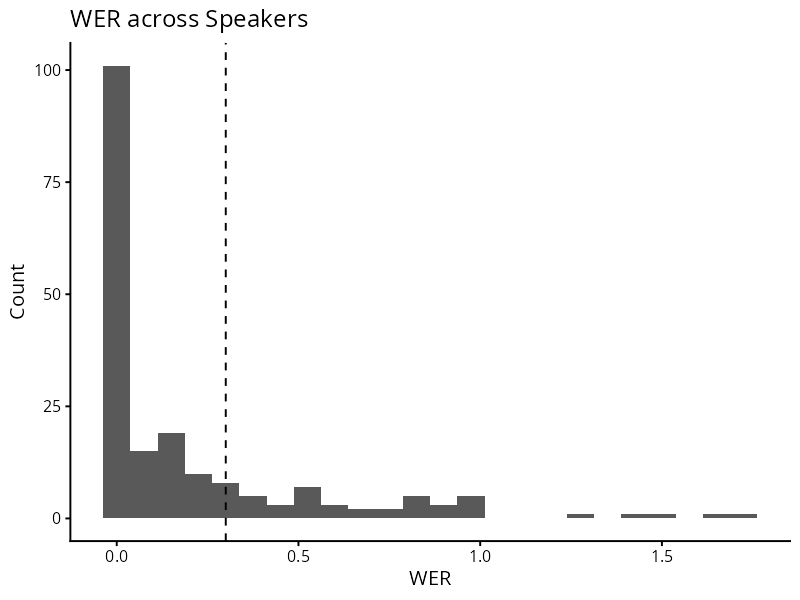

In [6]:
ggplot(speakers, aes(x=recording_wer)) +
geom_histogram(binwidth=0.15/2) +
labs(
    title = "WER across Speakers",
    x = "WER", y = "Count",
  ) +
geom_vline(xintercept=0.3, linetype="dashed") +
theme_classic(base_size=20)
ggsave("plots/wer_histogram.pdf")

In [7]:
ttsds_all <- read_csv("results/sap__sap_readable_01/aggregated_results_sap__sap_readable_01.csv")

Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): benchmark_category, dataset, noise_dataset, reference_dataset
dbl (3): score_mean, score_std, time_taken_sum

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
ttsds_all

# A tibble: 90 × 7
   benchmark_category dataset  score_mean score_std time_taken_sum noise_dataset
   <chr>              <chr>         <dbl>     <dbl>          <dbl> <chr>        
 1 SPEAKER            recordi…       92.4      7.81           373. noise_all_on…
 2 SPEAKER            e2-tts/…       91.7      7.35           300. noise_all_on…
 3 SPEAKER            maskgct…       91.0      8.53           318. noise_all_on…
 4 SPEAKER            vevo/ve…       90.8      7.68           285. noise_all_on…
 5 SPEAKER            gpt-sov…       90.2      8.03           235. noise_all_on…
 6 SPEAKER            indextt…       89.8      7.46           206. noise_all_on…
 7 SPEAKER            vibevoi…       89.5      7.64           272. noise_all_on…
 8 SPEAKER            f5-tts/…       88.9      8.89           198. noise_all_on…
 9 SPEAKER            qwen3-t…       88.1      9.45           232. noise_all_on…
10 SPEAKER            voicecr…       87.7      8.68           265. noise_all_on…
# ℹ 80 mo

In [9]:
system_name_map <- c(
  "e2-tts/default/eng" = "E2-TTS",
  "f5-tts/v1/eng" = "F5-TTS",
  "fish-speech/s1-mini/eng" = "Fishspeech",
  "gpt-sovits/v4/eng" = "GPT-SoVITS",
  "hierspeech/v1.1/eng" = "HierSpeech",
  "indextts/default/eng" = "IndexTTS2",
  "maskgct/default/eng" = "MaskGCT",
  "metavoice/default/eng" = "Metavoice",
  "openvoice/default/eng" = "OpenVoice",
  "qwen3-tts/1.7b-base/eng" = "Qwen3-TTS",
  "styletts2/default/eng" = "StyleTTS2",
  "tortoise/default/eng" = "TorToiSe",
  "vevo/vevo1.5/eng" = "Vevo",
  "vibevoice/default/eng" = "VibeVoice",
  "voicecraft/giga830m_tts_enhanced/eng" = "VoiceCraft",
  "whisperspeech/small/eng" = "WhisperSpeech",
  "xtts/v2/eng" = "XTTS",
  "recording/default/eng" = "Recording"
)

ttsds_all <- ttsds_all %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

ttsds_all

# A tibble: 18 × 6
   system        SPEAKER PROSODY OVERALL INTELLIGIBILITY GENERIC
   <chr>           <dbl>   <dbl>   <dbl>           <dbl>   <dbl>
 1 Recording        92.4    94.6    93.6            89.3    98.3
 2 E2-TTS           91.7    88.2    90.6            87.8    94.7
 3 MaskGCT          91.0    87.8    90.8            88.4    96.2
 4 Vevo             90.8    81.7    87.1            83.0    93.0
 5 GPT-SoVITS       90.2    86.4    87.3            82.1    90.4
 6 IndexTTS2        89.8    82.6    86.9            83.4    91.9
 7 VibeVoice        89.5    86.6    88.7            83.9    94.6
 8 F5-TTS           88.9    82.9    85.8            81.5    89.8
 9 Qwen3-TTS        88.1    84.2    86.4            82.5    91.0
10 VoiceCraft       87.7    87.2    88.3            82.9    95.2
11 WhisperSpeech    87.2    80.2    79.8            64.8    87.0
12 TorToiSe         87.2    79.0    82.5            75.0    88.6
13 HierSpeech       87.1    89.8    88.9            87.1    91.4
14 XTT

In [10]:
# Load LibriTTS reference TTSDS scores (needed for combined ranking)
ttsds_libritts <- read_csv("results/sap__libritts/aggregated_results_sap__libritts.csv") %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

ttsds_libritts_li <- read_csv("results/sap_very_high_wer__libritts/aggregated_results_sap_very_high_wer__libritts.csv") %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

# Add combined scores
ttsds_all <- ttsds_all %>%
  left_join(ttsds_libritts %>% select(system, INTEL_lib = INTELLIGIBILITY, OVERALL_lib = OVERALL), by = "system") %>%
  mutate(`LibriTTS Intel. + SAP Speaker` = (SPEAKER + INTEL_lib) / 2,
         `LibriTTS + SAP Overall` = (OVERALL + OVERALL_lib) / 2)

ttsds_all

Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): benchmark_category, dataset
dbl (3): score_mean, score_std, time_taken_sum
lgl (2): noise_dataset, reference_dataset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): benchmark_category, dataset
dbl (3): score_mean, score_std, time_taken_sum
lgl (2): noise_dataset, reference_dataset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 18 × 10
   system  SPEAKER PROSODY OVERALL INTELLIGIBILITY GENERIC INTEL_lib OVERALL_lib
   <chr>     <dbl>   <dbl>   <dbl>           <dbl>   <dbl>     <dbl>       <dbl>
 1 Record…    92.4    94.6    93.6            89.3    98.3      81.2        77.4
 2 E2-TTS     91.7    88.2    90.6            87.8    94.7      83.0        81.9
 3 MaskGCT    91.0    87.8    90.8            88.4    96.2      82.2        79.3
 4 Vevo       90.8    81.7    87.1            83.0    93.0      80.6        81.2
 5 GPT-So…    90.2    86.4    87.3            82.1    90.4      83.6        82.7
 6 IndexT…    89.8    82.6    86.9            83.4    91.9      83.9        85.3
 7 VibeVo…    89.5    86.6    88.7            83.9    94.6      83.5        83.0
 8 F5-TTS     88.9    82.9    85.8            81.5    89.8      83.2        85.2
 9 Qwen3-…    88.1    84.2    86.4            82.5    91.0      84.7        86.5
10 VoiceC…    87.7    87.2    88.3            82.9    95.2      80.9        78.6
11 Whisp

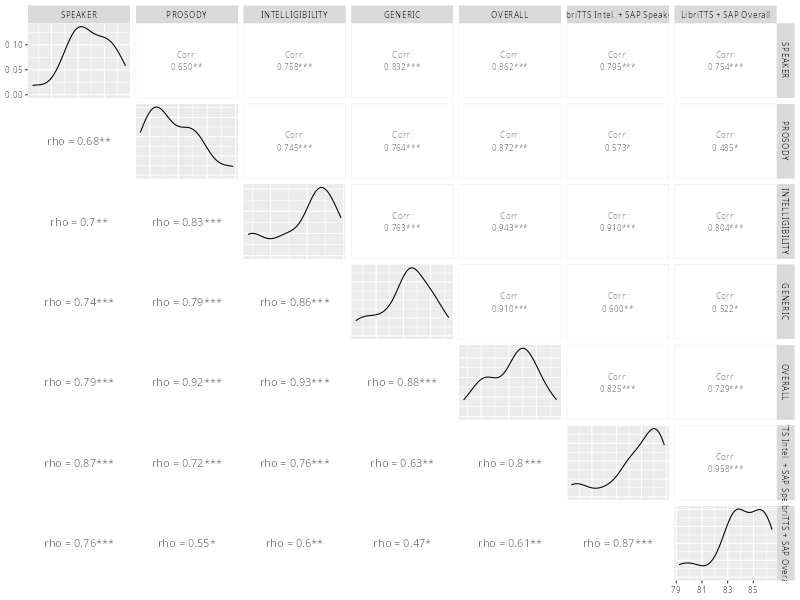

In [11]:
ggpairs(ttsds_all, columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL",
                               "LibriTTS Intel. + SAP Speaker", "LibriTTS + SAP Overall"),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag"))

In [12]:
# Load objective metrics
obj_spk_sim <- read_csv("results/all/objective/aggregated_spk_sim.csv")
obj_utmos   <- read_csv("results/all/objective/aggregated_utmos.csv")
obj_wer     <- read_csv("results/all/objective/aggregated_wer.csv")

# Load subjective metrics (BWS worth estimates)
subj_intel <- read_csv("results/all/subjective/intel_worth.csv")
subj_sim   <- read_csv("results/all/subjective/sim_worth.csv")

# Name mapping for objective files (short names -> display names)
obj_name_map <- c(
  "e2-tts" = "E2-TTS", "f5-tts" = "F5-TTS", "fish-speech" = "Fishspeech",
  "gpt-sovits" = "GPT-SoVITS", "hierspeech" = "HierSpeech", "indextts" = "IndexTTS2",
  "maskgct" = "MaskGCT", "metavoice" = "Metavoice", "openvoice" = "OpenVoice",
  "qwen3-tts" = "Qwen3-TTS", "styletts2" = "StyleTTS2", "tortoise" = "TorToiSe",
  "vevo" = "Vevo", "vibevoice" = "VibeVoice", "voicecraft" = "VoiceCraft",
  "whisperspeech" = "WhisperSpeech", "xtts" = "XTTS", "recording" = "Recording"
)

# Name mapping for subjective files (dot-separated -> display names)
subj_name_map <- c(
  "e2.tts" = "E2-TTS", "f5.tts" = "F5-TTS", "fish.speech" = "Fishspeech",
  "gpt.sovits" = "GPT-SoVITS", "hierspeech" = "HierSpeech", "indextts" = "IndexTTS2",
  "maskgct" = "MaskGCT", "metavoice" = "Metavoice", "openvoice" = "OpenVoice",
  "qwen3.tts" = "Qwen3-TTS", "styletts2" = "StyleTTS2", "tortoise" = "TorToiSe",
  "vevo" = "Vevo", "vibevoice" = "VibeVoice", "voicecraft" = "VoiceCraft",
  "whisperspeech" = "WhisperSpeech", "xtts" = "XTTS", "recording" = "Recording"
)

# Build objective table
objective <- obj_spk_sim %>%
  select(model, spk_sim = spk_sim_mean) %>%
  inner_join(obj_utmos %>% select(model, utmos = utmos_mean), by = "model") %>%
  inner_join(obj_wer %>% select(model, wer = wer_mean), by = "model") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, spk_sim, utmos, wer)

# Build subjective table
subjective <- subj_intel %>%
  select(item, subj_intel = estimate) %>%
  inner_join(subj_sim %>% select(item, subj_sim = estimate), by = "item") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, subj_intel, subj_sim)

# Join everything with TTSDS scores
all_metrics <- ttsds_all %>%
  inner_join(objective, by = "system") %>%
  inner_join(subjective, by = "system")

all_metrics

Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): spk_sim_mean, spk_sim_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): utmos_mean, utmos_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): wer_mean, wer_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1

# A tibble: 18 × 15
   system  SPEAKER PROSODY OVERALL INTELLIGIBILITY GENERIC INTEL_lib OVERALL_lib
   <chr>     <dbl>   <dbl>   <dbl>           <dbl>   <dbl>     <dbl>       <dbl>
 1 Record…    92.4    94.6    93.6            89.3    98.3      81.2        77.4
 2 E2-TTS     91.7    88.2    90.6            87.8    94.7      83.0        81.9
 3 MaskGCT    91.0    87.8    90.8            88.4    96.2      82.2        79.3
 4 Vevo       90.8    81.7    87.1            83.0    93.0      80.6        81.2
 5 GPT-So…    90.2    86.4    87.3            82.1    90.4      83.6        82.7
 6 IndexT…    89.8    82.6    86.9            83.4    91.9      83.9        85.3
 7 VibeVo…    89.5    86.6    88.7            83.9    94.6      83.5        83.0
 8 F5-TTS     88.9    82.9    85.8            81.5    89.8      83.2        85.2
 9 Qwen3-…    88.1    84.2    86.4            82.5    91.0      84.7        86.5
10 VoiceC…    87.7    87.2    88.3            82.9    95.2      80.9        78.6
11 Whisp

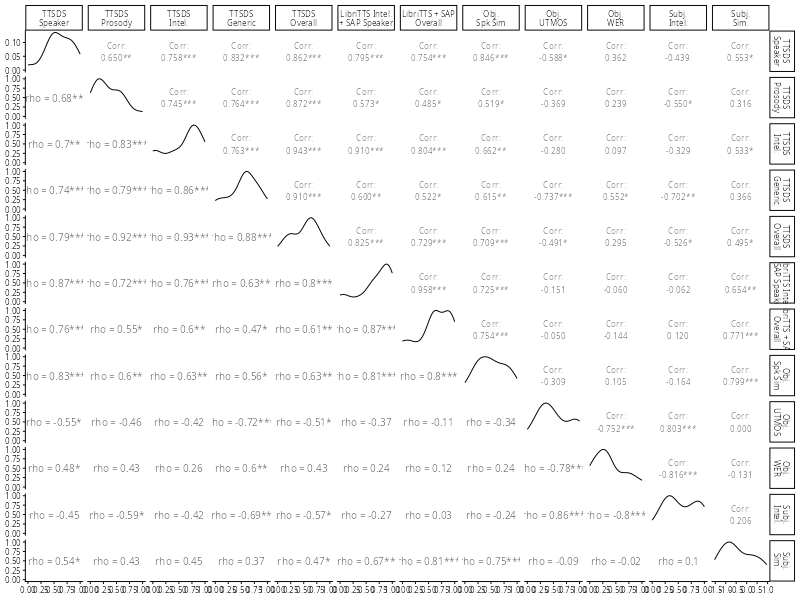

In [13]:
# Full exploratory pairs plot across all metrics
ggpairs(
  all_metrics,
  columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL",
              "LibriTTS Intel. + SAP Speaker", "LibriTTS + SAP Overall",
              "spk_sim", "utmos", "wer", "subj_intel", "subj_sim"),
  columnLabels = c("TTSDS\nSpeaker", "TTSDS\nProsody", "TTSDS\nIntel.", "TTSDS\nGeneric", "TTSDS\nOverall",
                   "LibriTTS Intel.\n+ SAP Speaker", "LibriTTS + SAP\nOverall",
                   "Obj.\nSpk Sim", "Obj.\nUTMOS", "Obj.\nWER", "Subj.\nIntel.", "Subj.\nSim."),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")
) +
  theme_classic(base_size = 10)
ggsave("plots/all_metrics_ggpairs.pdf", width = 16, height = 16)

In [14]:
# --- Combined Rankings (All Speakers) ---
cat("=== LibriTTS Intel. + SAP Speaker Ranking (All Speakers) ===\n")
ttsds_all %>%
  select(system, SPEAKER, INTEL_lib, `LibriTTS Intel. + SAP Speaker`) %>%
  arrange(desc(`LibriTTS Intel. + SAP Speaker`)) %>%
  mutate(rank = row_number()) %>%
  select(rank, system, SPEAKER, INTEL_lib, `LibriTTS Intel. + SAP Speaker`) %>%
  print(n = Inf)

cat("\n=== LibriTTS + SAP Overall Ranking (All Speakers) ===\n")
ttsds_all %>%
  select(system, OVERALL, OVERALL_lib, `LibriTTS + SAP Overall`) %>%
  arrange(desc(`LibriTTS + SAP Overall`)) %>%
  mutate(rank = row_number()) %>%
  select(rank, system, OVERALL, OVERALL_lib, `LibriTTS + SAP Overall`) %>%
  print(n = Inf)

=== LibriTTS Intel. + SAP Speaker Ranking (All Speakers) ===
# A tibble: 18 × 5
    rank system        SPEAKER INTEL_lib `LibriTTS Intel. + SAP Speaker`
   <int> <chr>           <dbl>     <dbl>                           <dbl>
 1     1 E2-TTS           91.7      83.0                            87.3
 2     2 GPT-SoVITS       90.2      83.6                            86.9
 3     3 IndexTTS2        89.8      83.9                            86.9
 4     4 Recording        92.4      81.2                            86.8
 5     5 MaskGCT          91.0      82.2                            86.6
 6     6 VibeVoice        89.5      83.5                            86.5
 7     7 Qwen3-TTS        88.1      84.7                            86.4
 8     8 F5-TTS           88.9      83.2                            86.0
 9     9 Vevo             90.8      80.6                            85.7
10    10 HierSpeech       87.1      83.2                            85.2
11    11 XTTS             86.6      83.6    

In [15]:
# --- Low Intelligibility subset ---

# Load TTSDS results for low intelligibility
ttsds_low_intel <- read_csv("results/sap_very_high_wer__sap_readable_01_very_high_wer/aggregated_results_sap_very_high_wer__sap_readable_01_very_high_wer.csv")

ttsds_low_intel <- ttsds_low_intel %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

# Add combined scores
ttsds_low_intel <- ttsds_low_intel %>%
  left_join(ttsds_libritts_li %>% select(system, INTEL_lib = INTELLIGIBILITY, OVERALL_lib = OVERALL), by = "system") %>%
  mutate(`LibriTTS Intel. + SAP Speaker` = (SPEAKER + INTEL_lib) / 2,
         `LibriTTS + SAP Overall` = (OVERALL + OVERALL_lib) / 2)

# Load objective metrics (low intelligibility)
obj_spk_sim_li <- read_csv("results/very_high_wer/objective/aggregated_spk_sim.csv")
obj_utmos_li   <- read_csv("results/very_high_wer/objective/aggregated_utmos.csv")
obj_wer_li     <- read_csv("results/very_high_wer/objective/aggregated_wer.csv")

# Load subjective metrics (low intelligibility)
subj_intel_li <- read_csv("results/very_high_wer/subjective/intel_worth.csv")
subj_sim_li   <- read_csv("results/very_high_wer/subjective/sim_worth.csv")

# Build objective table (low intelligibility)
objective_li <- obj_spk_sim_li %>%
  select(model, spk_sim = spk_sim_mean) %>%
  inner_join(obj_utmos_li %>% select(model, utmos = utmos_mean), by = "model") %>%
  inner_join(obj_wer_li %>% select(model, wer = wer_mean), by = "model") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, spk_sim, utmos, wer)

# Build subjective table (low intelligibility)
subjective_li <- subj_intel_li %>%
  select(item, subj_intel = estimate) %>%
  inner_join(subj_sim_li %>% select(item, subj_sim = estimate), by = "item") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, subj_intel, subj_sim)

# Join everything
all_metrics_low_intel <- ttsds_low_intel %>%
  inner_join(objective_li, by = "system") %>%
  inner_join(subjective_li, by = "system")

all_metrics_low_intel

Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): benchmark_category, dataset
dbl (3): score_mean, score_std, time_taken_sum
lgl (2): noise_dataset, reference_dataset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): spk_sim_mean, spk_sim_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): utmos_mean, utmos_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the colum

# A tibble: 18 × 15
   system  SPEAKER PROSODY OVERALL INTELLIGIBILITY GENERIC INTEL_lib OVERALL_lib
   <chr>     <dbl>   <dbl>   <dbl>           <dbl>   <dbl>     <dbl>       <dbl>
 1 Record…    85.4    90.7    89.9            87.3    96.2      77.2        70.1
 2 E2-TTS     84.7    85.8    86.5            84.2    91.3      79.2        76.5
 3 MaskGCT    84.6    84.2    86.9            85.7    93.2      78.1        73.2
 4 IndexT…    83.8    81.7    84.4            83.7    88.6      81.5        78.1
 5 GPT-So…    83.5    85.3    84.6            83.0    86.4      81.3        76.9
 6 Vevo       83.2    77.1    82.9            82.2    88.9      77.1        72.9
 7 VibeVo…    82.8    85.6    86.0            83.2    92.6      79.7        76.1
 8 F5-TTS     81.4    82.0    82.5            80.5    86.0      80.5        79.9
 9 XTTS       80.6    81.2    82.8            81.6    87.9      80.8        76.0
10 VoiceC…    80.6    83.9    84.1            80.6    91.4      76.7        73.5
11 HierS

Saving 6.67 x 6.67 in image


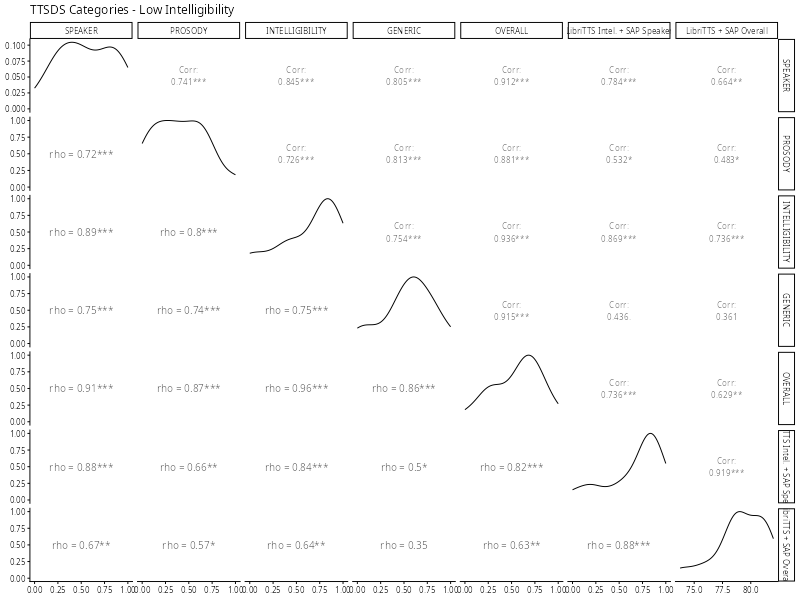

In [16]:
ggpairs(ttsds_low_intel, columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL",
                                     "LibriTTS Intel. + SAP Speaker", "LibriTTS + SAP Overall"),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")) +
  theme_classic(base_size = 10) +
  ggtitle("TTSDS Categories - Low Intelligibility")
ggsave("plots/ttsds_ggpairs_low_intel.pdf")

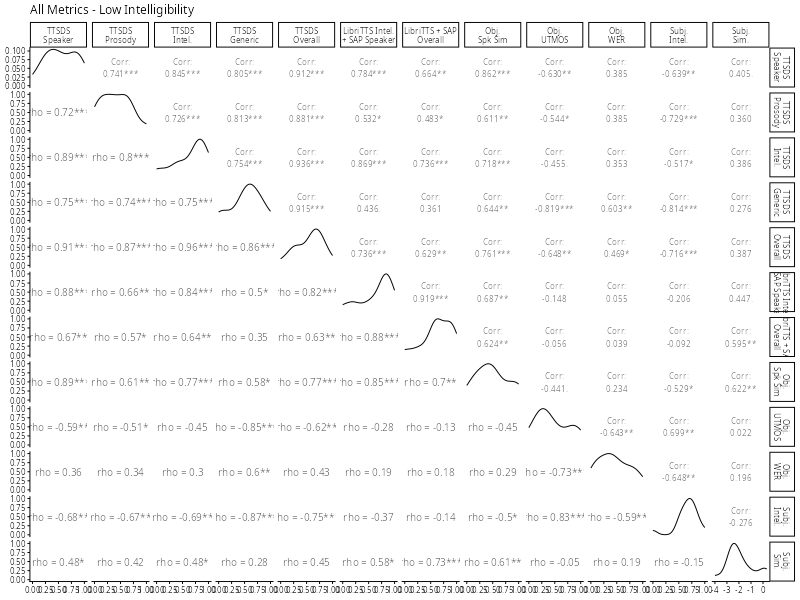

In [17]:
# Full exploratory pairs plot - Low Intelligibility
ggpairs(
  all_metrics_low_intel,
  columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL",
              "LibriTTS Intel. + SAP Speaker", "LibriTTS + SAP Overall",
              "spk_sim", "utmos", "wer", "subj_intel", "subj_sim"),
  columnLabels = c("TTSDS\nSpeaker", "TTSDS\nProsody", "TTSDS\nIntel.", "TTSDS\nGeneric", "TTSDS\nOverall",
                   "LibriTTS Intel.\n+ SAP Speaker", "LibriTTS + SAP\nOverall",
                   "Obj.\nSpk Sim", "Obj.\nUTMOS", "Obj.\nWER", "Subj.\nIntel.", "Subj.\nSim."),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")
) +
  theme_classic(base_size = 10) +
  ggtitle("All Metrics - Low Intelligibility")
ggsave("plots/all_metrics_ggpairs_low_intel.pdf", width = 16, height = 16)

In [18]:
cat("=== LibriTTS Intel. + SAP Speaker Ranking (Low Intelligibility) ===\n")
ttsds_low_intel %>%
  select(system, SPEAKER, INTEL_lib, `LibriTTS Intel. + SAP Speaker`) %>%
  arrange(desc(`LibriTTS Intel. + SAP Speaker`)) %>%
  mutate(rank = row_number()) %>%
  select(rank, system, SPEAKER, INTEL_lib, `LibriTTS Intel. + SAP Speaker`) %>%
  print(n = Inf)

cat("\n=== LibriTTS + SAP Overall Ranking (Low Intelligibility) ===\n")
ttsds_low_intel %>%
  select(system, OVERALL, OVERALL_lib, `LibriTTS + SAP Overall`) %>%
  arrange(desc(`LibriTTS + SAP Overall`)) %>%
  mutate(rank = row_number()) %>%
  select(rank, system, OVERALL, OVERALL_lib, `LibriTTS + SAP Overall`) %>%
  print(n = Inf)

=== LibriTTS Intel. + SAP Speaker Ranking (Low Intelligibility) ===
# A tibble: 18 × 5
    rank system        SPEAKER INTEL_lib `LibriTTS Intel. + SAP Speaker`
   <int> <chr>           <dbl>     <dbl>                           <dbl>
 1     1 IndexTTS2        83.8      81.5                            82.7
 2     2 GPT-SoVITS       83.5      81.3                            82.4
 3     3 E2-TTS           84.7      79.2                            82.0
 4     4 Recording        85.4      77.2                            81.3
 5     5 MaskGCT          84.6      78.1                            81.3
 6     6 VibeVoice        82.8      79.7                            81.3
 7     7 Qwen3-TTS        79.6      82.6                            81.1
 8     8 F5-TTS           81.4      80.5                            81.0
 9     9 XTTS             80.6      80.8                            80.7
10    10 HierSpeech       80.0      80.4                            80.2
11    11 Vevo             83.2      7

In [19]:
# --- Load TTSDS with LibriTTS reference ---

# All speakers, LibriTTS reference (reload clean copy for correlation comparison)
ttsds_libritts <- read_csv("results/sap__libritts/aggregated_results_sap__libritts.csv") %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

# Low intelligibility, LibriTTS reference
ttsds_libritts_li <- read_csv("results/sap_very_high_wer__libritts/aggregated_results_sap_very_high_wer__libritts.csv") %>%
  filter(dataset %in% names(system_name_map)) %>%
  mutate(system = system_name_map[dataset]) %>%
  select(system, benchmark_category, score_mean) %>%
  pivot_wider(names_from = benchmark_category, values_from = score_mean)

# Rename columns for joining: suffix _lib for LibriTTS reference
rename_lib <- function(df) {
  df %>% rename_with(~ paste0(.x, "_lib"), -system)
}

# --- Correlate SAP-readable vs LibriTTS reference (All speakers) ---
compare_all <- ttsds_all %>%
  select(system, SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL) %>%
  inner_join(rename_lib(ttsds_libritts), by = "system")

cat("=== All Speakers: SAP-readable vs LibriTTS reference ===\n")
for (cat_name in c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL")) {
  sap_col <- cat_name
  lib_col <- paste0(cat_name, "_lib")
  if (sap_col %in% names(compare_all) && lib_col %in% names(compare_all)) {
    r <- cor(compare_all[[sap_col]], compare_all[[lib_col]], use = "complete.obs")
    rho <- cor(compare_all[[sap_col]], compare_all[[lib_col]], method = "spearman", use = "complete.obs")
    cat(sprintf("  %s: Pearson r = %.3f, Spearman rho = %.3f\n", cat_name, r, rho))
  }
}

# --- Correlate SAP-readable vs LibriTTS reference (Low intelligibility) ---
compare_li <- ttsds_low_intel %>%
  select(system, SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL) %>%
  inner_join(rename_lib(ttsds_libritts_li), by = "system")

cat("\n=== Low Intelligibility: SAP-readable vs LibriTTS reference ===\n")
for (cat_name in c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC", "OVERALL")) {
  sap_col <- cat_name
  lib_col <- paste0(cat_name, "_lib")
  if (sap_col %in% names(compare_li) && lib_col %in% names(compare_li)) {
    r <- cor(compare_li[[sap_col]], compare_li[[lib_col]], use = "complete.obs")
    rho <- cor(compare_li[[sap_col]], compare_li[[lib_col]], method = "spearman", use = "complete.obs")
    cat(sprintf("  %s: Pearson r = %.3f, Spearman rho = %.3f\n", cat_name, r, rho))
  }
}

Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): benchmark_category, dataset
dbl (3): score_mean, score_std, time_taken_sum
lgl (2): noise_dataset, reference_dataset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 90 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): benchmark_category, dataset
dbl (3): score_mean, score_std, time_taken_sum
lgl (2): noise_dataset, reference_dataset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
=== All Speakers: SAP-readable vs LibriTTS reference ===
  SPEAKER: Pearson r = -0.191, Spearman rho = -0.195
  PROSODY: Pearson r = -0.882, Spearman rho = -0.864
  INTELLIGIBILITY: Pearson r = 0.796, Spear

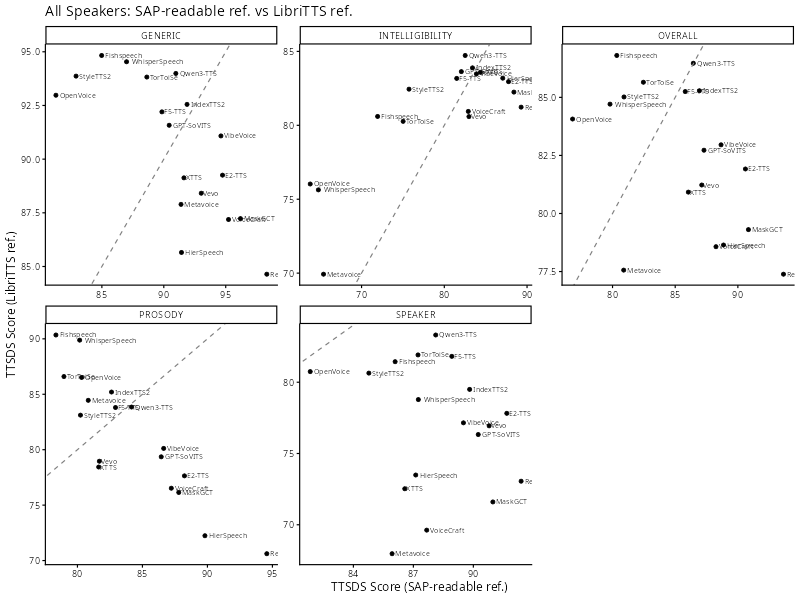

In [20]:
# Scatter plots: SAP-readable ref vs LibriTTS ref per category (All speakers)
compare_all_long <- compare_all %>%
  select(system, SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL,
         SPEAKER_lib, PROSODY_lib, INTELLIGIBILITY_lib, GENERIC_lib, OVERALL_lib) %>%
  pivot_longer(cols = c(SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL),
               names_to = "category", values_to = "sap_ref") %>%
  mutate(lib_col = paste0(category, "_lib")) %>%
  rowwise() %>%
  mutate(lib_ref = compare_all[[lib_col]][compare_all$system == system]) %>%
  ungroup() %>%
  select(system, category, sap_ref, lib_ref)

ggplot(compare_all_long, aes(x = sap_ref, y = lib_ref, label = system)) +
  geom_point() +
  geom_text(hjust = -0.1, size = 2.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  facet_wrap(~category, scales = "free") +
  labs(title = "All Speakers: SAP-readable ref. vs LibriTTS ref.",
       x = "TTSDS Score (SAP-readable ref.)", y = "TTSDS Score (LibriTTS ref.)") +
  theme_classic(base_size = 12)
ggsave("plots/ttsds_ref_comparison_all.pdf", width = 12, height = 8)

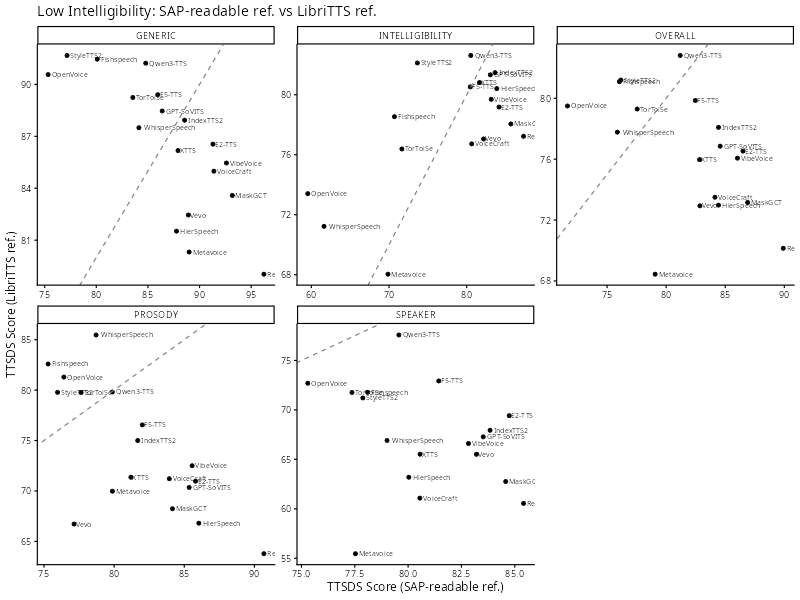

In [21]:
# Scatter plots: SAP-readable ref vs LibriTTS ref per category (Low intelligibility)
compare_li_long <- compare_li %>%
  select(system, SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL,
         SPEAKER_lib, PROSODY_lib, INTELLIGIBILITY_lib, GENERIC_lib, OVERALL_lib) %>%
  pivot_longer(cols = c(SPEAKER, PROSODY, INTELLIGIBILITY, GENERIC, OVERALL),
               names_to = "category", values_to = "sap_ref") %>%
  mutate(lib_col = paste0(category, "_lib")) %>%
  rowwise() %>%
  mutate(lib_ref = compare_li[[lib_col]][compare_li$system == system]) %>%
  ungroup() %>%
  select(system, category, sap_ref, lib_ref)

ggplot(compare_li_long, aes(x = sap_ref, y = lib_ref, label = system)) +
  geom_point() +
  geom_text(hjust = -0.1, size = 2.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  facet_wrap(~category, scales = "free") +
  labs(title = "Low Intelligibility: SAP-readable ref. vs LibriTTS ref.",
       x = "TTSDS Score (SAP-readable ref.)", y = "TTSDS Score (LibriTTS ref.)") +
  theme_classic(base_size = 12)
ggsave("plots/ttsds_ref_comparison_low_intel.pdf", width = 12, height = 8)

Saving 6.67 x 6.67 in image


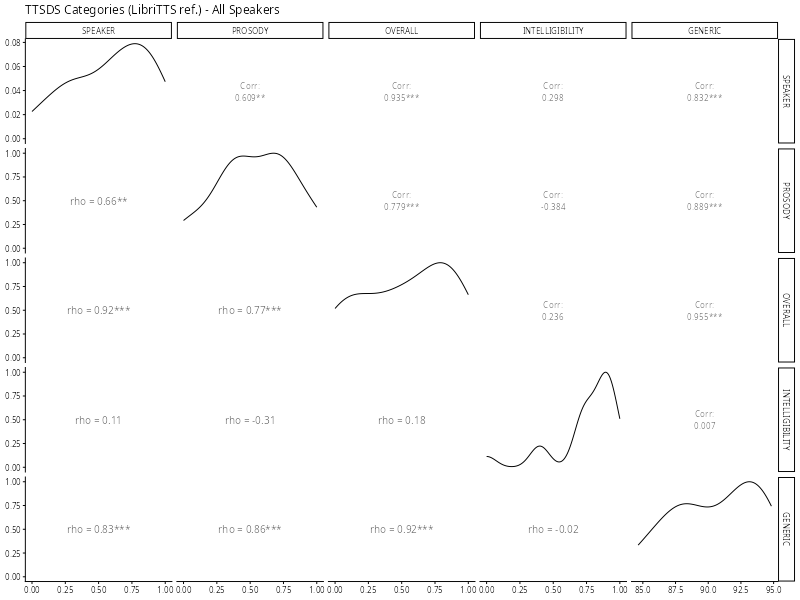

In [22]:
# --- ggpairs with LibriTTS reference TTSDS scores ---

# TTSDS-only ggpairs (All speakers, LibriTTS ref)
ggpairs(ttsds_libritts, columns = 2:ncol(ttsds_libritts),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")) +
  theme_classic(base_size = 10) +
  ggtitle("TTSDS Categories (LibriTTS ref.) - All Speakers")
ggsave("plots/ttsds_ggpairs_libritts.pdf")

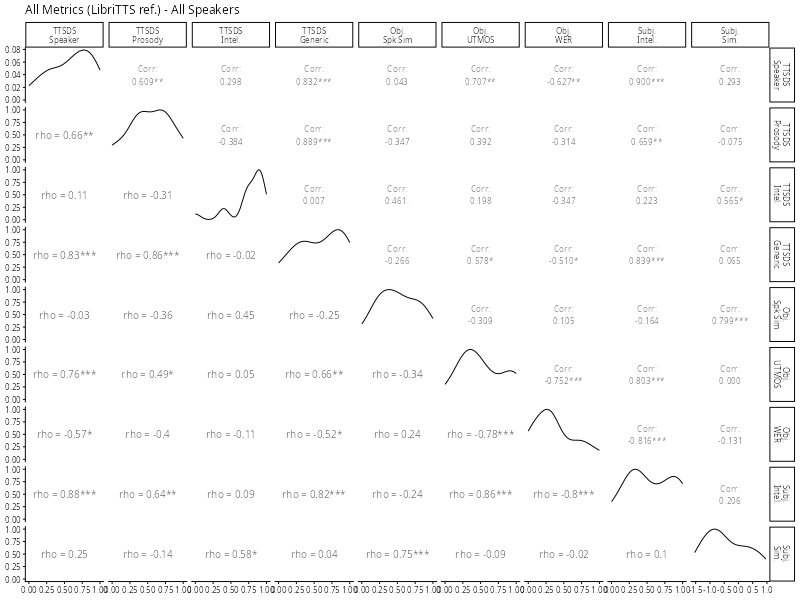

In [23]:
# Full all_metrics ggpairs (All speakers, LibriTTS ref)
all_metrics_libritts <- ttsds_libritts %>%
  inner_join(objective, by = "system") %>%
  inner_join(subjective, by = "system")

ggpairs(
  all_metrics_libritts,
  columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC",
              "spk_sim", "utmos", "wer", "subj_intel", "subj_sim"),
  columnLabels = c("TTSDS\nSpeaker", "TTSDS\nProsody", "TTSDS\nIntel.", "TTSDS\nGeneric",
                   "Obj.\nSpk Sim", "Obj.\nUTMOS", "Obj.\nWER", "Subj.\nIntel.", "Subj.\nSim."),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")
) +
  theme_classic(base_size = 10) +
  ggtitle("All Metrics (LibriTTS ref.) - All Speakers")
ggsave("plots/all_metrics_ggpairs_libritts.pdf", width = 14, height = 14)

Saving 6.67 x 6.67 in image


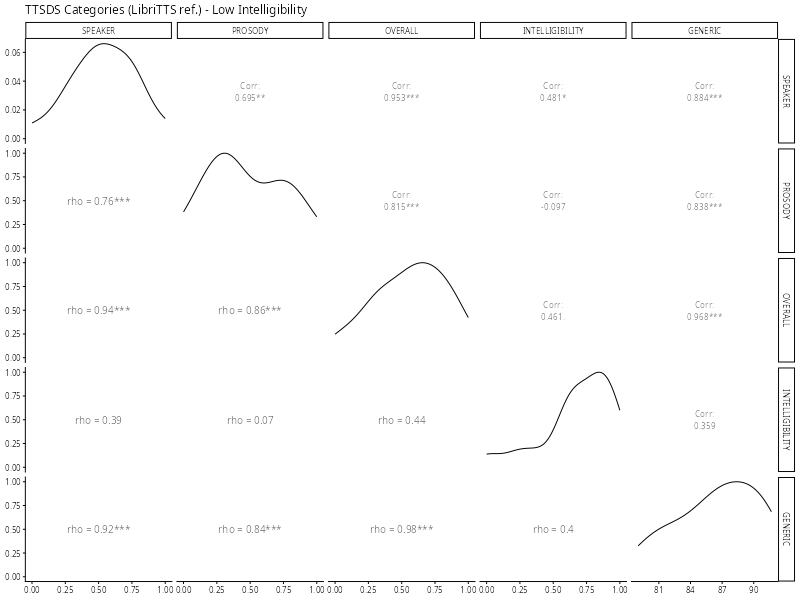

In [24]:
# TTSDS-only ggpairs (Low intelligibility, LibriTTS ref)
ggpairs(ttsds_libritts_li, columns = 2:ncol(ttsds_libritts_li),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")) +
  theme_classic(base_size = 10) +
  ggtitle("TTSDS Categories (LibriTTS ref.) - Low Intelligibility")
ggsave("plots/ttsds_ggpairs_libritts_low_intel.pdf")

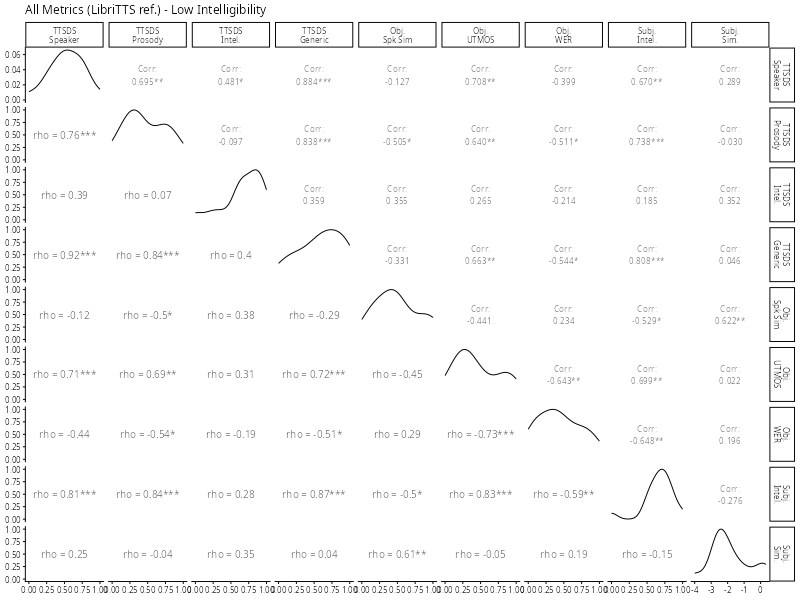

In [25]:
# Full all_metrics ggpairs (Low intelligibility, LibriTTS ref)
all_metrics_libritts_li <- ttsds_libritts_li %>%
  inner_join(objective_li, by = "system") %>%
  inner_join(subjective_li, by = "system")

ggpairs(
  all_metrics_libritts_li,
  columns = c("SPEAKER", "PROSODY", "INTELLIGIBILITY", "GENERIC",
              "spk_sim", "utmos", "wer", "subj_intel", "subj_sim"),
  columnLabels = c("TTSDS\nSpeaker", "TTSDS\nProsody", "TTSDS\nIntel.", "TTSDS\nGeneric",
                   "Obj.\nSpk Sim", "Obj.\nUTMOS", "Obj.\nWER", "Subj.\nIntel.", "Subj.\nSim."),
  upper = list(continuous = wrap("cor", size = 3)),
  lower = list(continuous = cor_spearman),
  diag = list(continuous = "densityDiag")
) +
  theme_classic(base_size = 10) +
  ggtitle("All Metrics (LibriTTS ref.) - Low Intelligibility")
ggsave("plots/all_metrics_ggpairs_libritts_low_intel.pdf", width = 14, height = 14)